In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery, NetWeighted, NetDiscoveryWeighted
from diff_equations import grad, cooling_law
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


# Configuration

In [2]:
#Parameters:
duration = 1000
data_generation_interval = 1000
number_of_points = 100
noise_coeff = 2

pinn_collocation_points = 1000
parameter_discovery_collocation_points = 1000

# Used with NetWeighted/NetDiscoveryWeighted below, where loss1_weight (data) +
# loss2_weight (physics) must sum to 1. loss1_weight is derived automatically
# as 1 - loss2_weight. Values keep the original 2:1 (physics:data) ratio.
pinn_loss_weight = 2/3
parameter_discovery_loss__weight = 2/3

vanila_epochs = 200
pinn_epochs = 200
parameter_discovery_epochs = 200

#Primary conditions
Tenv = 25
T0 = 100
#Cooling rate
R = 0.005

np.random.seed(10)
sns.set_theme()
torch.manual_seed(42)


# Data Generation

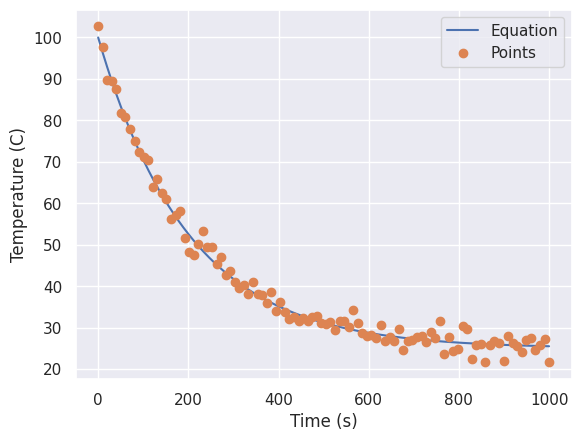

In [3]:
times = np.linspace(0, duration, duration)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, data_generation_interval, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Points'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

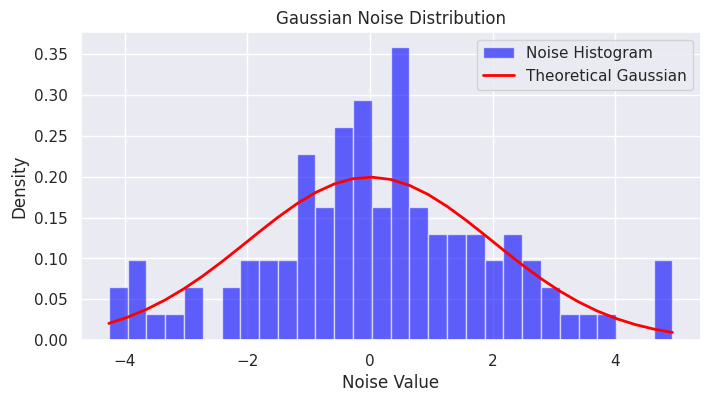

In [4]:
noise = T - eq(t)

plt.figure(figsize=(8, 4))
count, bins, ignored = plt.hist(noise, bins=30, density=True, alpha=0.6, color='blue', label='Noise Histogram')

mu = 0
sigma = noise_coeff
theoretical_gaussian = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(- (bins - mu)**2 / (2 * sigma**2))

plt.plot(bins, theoretical_gaussian, linewidth=2, color='red', label='Theoretical Gaussian')

plt.title('Gaussian Noise Distribution')
plt.ylabel('Density')
plt.xlabel('Noise Value')
plt.legend()
plt.show()

# Spliting Data

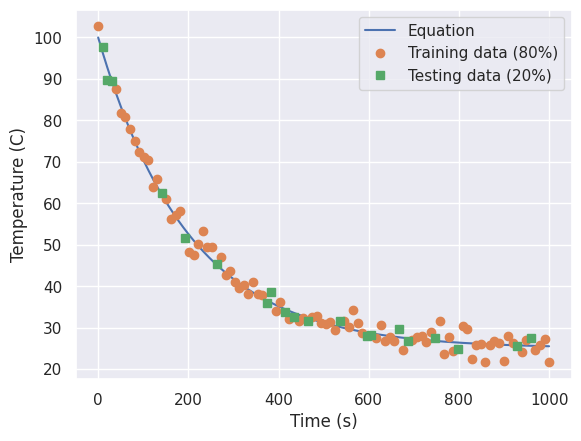

In [5]:
x_train, x_test, y_train, y_test = train_test_split(t, T, test_size=0.2, random_state=10)

plt.plot(times, temps)
plt.plot(x_train, y_train, 'o') 
plt.plot(x_test, y_test, 's')   
plt.legend(['Equation', 'Training data (80%)', 'Testing data (20%)'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

# Normalization

In [6]:
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
times_reshaped = times.reshape(-1, 1)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
temps_reshaped = temps.reshape(-1, 1)

x_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)
times_scaled = x_scaler.transform(times_reshaped)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)
temps_scaled = y_scaler.transform(temps_reshaped)

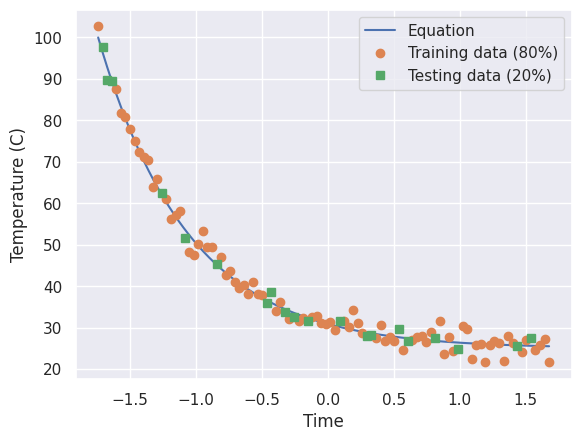

In [7]:
plt.plot(times_scaled, temps, label='Equation')
plt.plot(x_train_scaled, y_train, 'o', label='Training data (80%)') 
plt.plot(x_test_scaled, y_test, 's', label='Testing data (20%)')   

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.show()

# Regression

In [8]:
ml_model = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
ml_model.fit(x_train_scaled, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=4)),
                ('linearregression', LinearRegression())])

Mean Squared Error: 2.2923


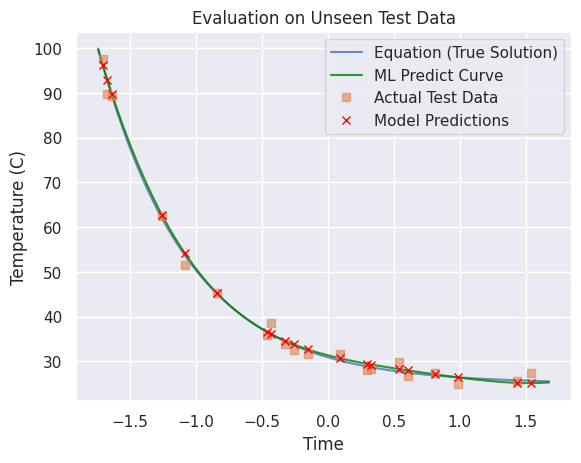

In [9]:
T_pred = ml_model.predict(x_test_scaled)
test_mse = np.mean((T_pred - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

continuous_preds = ml_model.predict(times_scaled)

plt.figure()

plt.plot(times_scaled, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times_scaled, continuous_preds, label='ML Predict Curve', color='green', alpha=0.8)

plt.plot(x_test_scaled, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test_scaled, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.title('Evaluation on Unseen Test Data')
plt.show()

# TRF

The mathematical representation is $f(x) = ax^4 + bx^3 + cx^2 + dx + e$ for this specific model.

In [10]:
def quartic_polynomial(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

x_data = x_train_scaled.flatten()
y_data = y_train_scaled.flatten()

popt, pcov = curve_fit(
    f=quartic_polynomial, 
    xdata=x_data, 
    ydata=y_data, 
    method='trf'
)

a, b, c, d, e = popt
print(f"Fitted parameters: a={a}, b={b}, c={c}, d={d}, e={e}")

Fitted parameters: a=0.08527500045862031, b=-0.25035186577294477, c=0.3155393338556459, d=-0.4282921367913689, e=-0.46300709636572057


Mean Squared Error: 2.2923


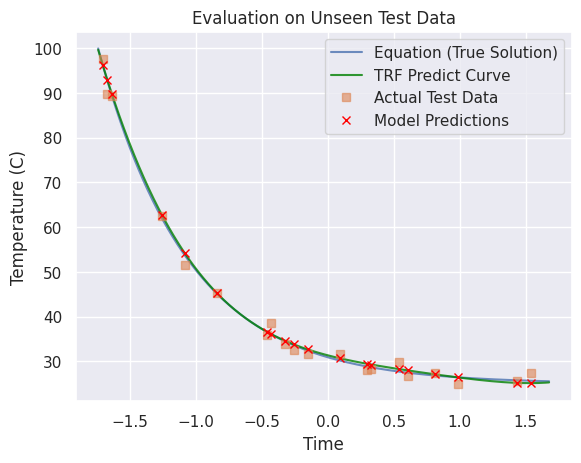

In [11]:
y_pred_scaled = quartic_polynomial(x_data, a, b, c, d, e)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

T_pred_scaled = quartic_polynomial(x_test_scaled.flatten(), a, b, c, d, e)
T_pred = y_scaler.inverse_transform(T_pred_scaled.reshape(-1, 1))

test_mse = np.mean((T_pred - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

continuous_preds_scaled = quartic_polynomial(times_scaled.flatten(), a, b, c, d, e)
continuous_preds = y_scaler.inverse_transform(continuous_preds_scaled.reshape(-1, 1))

plt.figure()

plt.plot(times_scaled, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times_scaled, continuous_preds, label='TRF Predict Curve', color='green', alpha=0.8)

plt.plot(x_test_scaled, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test_scaled, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.title('Evaluation on Unseen Test Data')
plt.show()

# Vanilla Network

Epoch 0/200, loss: 2.01
Epoch 20/200, loss: 1.22
Epoch 40/200, loss: 1.03
Epoch 60/200, loss: 1.02
Epoch 80/200, loss: 1.02
Epoch 100/200, loss: 1.01
Epoch 120/200, loss: 1.01
Epoch 140/200, loss: 1.01
Epoch 160/200, loss: 1.01
Epoch 180/200, loss: 1.01


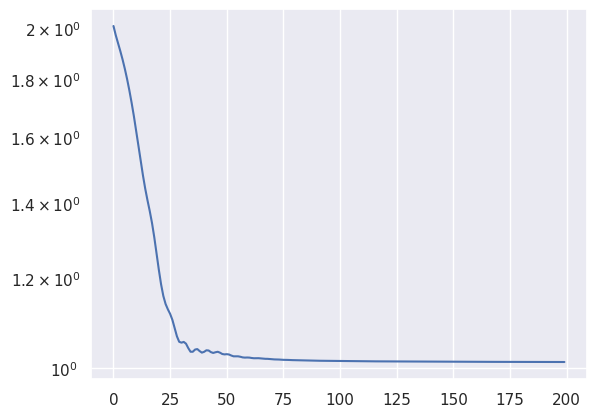

In [12]:
data_loss = 1
net = Net(1,1,loss2=lambda model: data_loss , loss2_weight=1, epochs=vanila_epochs, lr=1e-3).to(DEVICE)

losses = net.fit(x_train_scaled, y_train_scaled)

plt.plot(losses)
plt.yscale('log')

Mean Squared Error: 2.3963


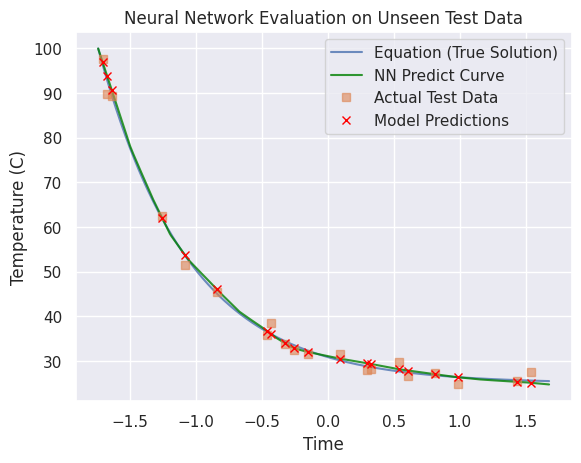

In [13]:
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32).to(DEVICE)
times_tensor = torch.tensor(times_scaled, dtype=torch.float32).to(DEVICE)

net.eval()
with torch.no_grad():
    # Model outputs scaled predictions (0 to 1)
    T_pred_scaled = net(x_test_tensor).cpu().numpy()
    continuous_preds_scaled = net(times_tensor).cpu().numpy()

#Convert predictions back to original Celsius scale
T_pred = y_scaler.inverse_transform(T_pred_scaled)
continuous_preds = y_scaler.inverse_transform(continuous_preds_scaled)

# Calculate MSE using the original unscaled y_test
test_mse = np.mean((T_pred.flatten() - y_test.flatten())**2)
print(f"Mean Squared Error: {test_mse:.4f}")

plt.figure()

# Plot using the unscaled temps and y_test for the Y-axis
plt.plot(times_scaled, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times_scaled, continuous_preds, label='NN Predict Curve', color='green', alpha=0.8)

plt.plot(x_test_scaled, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test_scaled, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.title('Neural Network Evaluation on Unseen Test Data')
plt.show()

# PINN

In [14]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    x_mean, x_std = float(x_scaler.mean_[0]), float(x_scaler.scale_[0])
    y_mean, y_std = float(y_scaler.mean_[0]), float(y_scaler.scale_[0])

    # collocation points in the SAME standardized domain the network is trained/evaluated on
    t_raw = torch.linspace(0, 1000, steps=n_points).view(-1, 1)
    ts = ((t_raw - x_mean) / x_std).requires_grad_(True).to(DEVICE)

    z = model(ts)                      # standardized temperature prediction
    dz_dx = grad(z, ts)[0]

    temps = z * y_std + y_mean          # back to Celsius
    dT = dz_dx * (y_std / x_std)        # chain rule: d(temp)/d(real time)
    pde_loss = torch.mean((R * (Tenv - temps) - dT) ** 2)

    # anchor the solution to the known initial condition T(0) = T0
    t0 = torch.tensor([[(0.0 - x_mean) / x_std]], dtype=torch.float32).to(DEVICE)
    z0 = model(t0)
    ic_loss = (z0 - (T0 - y_mean) / y_std) ** 2

    return pde_loss + ic_loss.mean()

data_loss_weight (loss1_weight): 0.33333333333333337, physics_loss_weight (loss2_weight): 0.6666666666666666
Epoch 0/200, loss: 7.5908, data_loss: 0.9885, physics_loss: 10.8920
Epoch 20/200, loss: 0.8292, data_loss: 1.5705, physics_loss: 0.4585
Epoch 40/200, loss: 0.1644, data_loss: 0.4568, physics_loss: 0.0182
Epoch 60/200, loss: 0.0473, data_loss: 0.0890, physics_loss: 0.0265
Epoch 80/200, loss: 0.0218, data_loss: 0.0528, physics_loss: 0.0063
Epoch 100/200, loss: 0.0151, data_loss: 0.0408, physics_loss: 0.0022
Epoch 120/200, loss: 0.0098, data_loss: 0.0266, physics_loss: 0.0015
Epoch 140/200, loss: 0.0069, data_loss: 0.0191, physics_loss: 0.0008
Epoch 160/200, loss: 0.0055, data_loss: 0.0156, physics_loss: 0.0005
Epoch 180/200, loss: 0.0048, data_loss: 0.0136, physics_loss: 0.0004


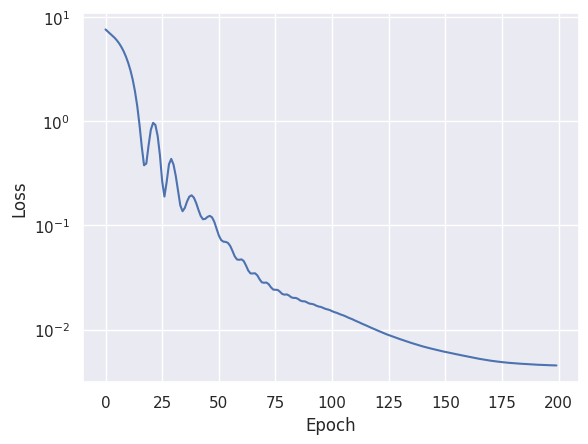

In [15]:
net = NetWeighted(1, 1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss_weight, lr=1e-3).to(DEVICE)
print(f"data_loss_weight (loss1_weight): {net.loss1_weight}, physics_loss_weight (loss2_weight): {net.loss2_weight}")

losses = net.fit(x_train_scaled, y_train_scaled)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Mean Squared Error: 2.9384


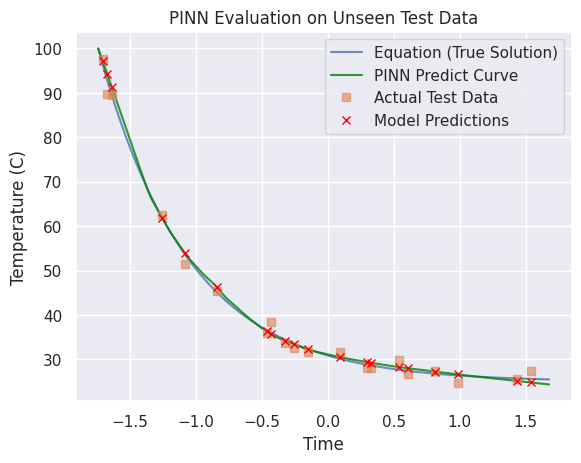

In [16]:
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32).to(DEVICE)
times_tensor = torch.tensor(times_scaled, dtype=torch.float32).to(DEVICE)

net.eval()
with torch.no_grad():
    T_pred_scaled = net(x_test_tensor).cpu().numpy()
    continuous_preds_scaled = net(times_tensor).cpu().numpy()

T_pred = y_scaler.inverse_transform(T_pred_scaled)
continuous_preds = y_scaler.inverse_transform(continuous_preds_scaled)

test_mse = np.mean((T_pred.flatten() - y_test.flatten())**2)
print(f"Mean Squared Error: {test_mse:.4f}")

plt.figure()

plt.plot(times_scaled, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times_scaled, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

plt.plot(x_test_scaled, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test_scaled, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.title('PINN Evaluation on Unseen Test Data')
plt.show()

# Parameter Discovery

In [17]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points):
    x_mean, x_std = float(x_scaler.mean_[0]), float(x_scaler.scale_[0])
    y_mean, y_std = float(y_scaler.mean_[0]), float(y_scaler.scale_[0])

    # collocation points in the SAME standardized domain the network is trained/evaluated on
    t_raw = torch.linspace(0, 1000, steps=n_points).view(-1, 1)
    ts = ((t_raw - x_mean) / x_std).requires_grad_(True).to(DEVICE)

    z = model(ts)                      # standardized temperature prediction
    dz_dx = grad(z, ts)[0]

    temps = z * y_std + y_mean          # back to Celsius
    dT = dz_dx * (y_std / x_std)        # chain rule: d(temp)/d(real time)
    pde_loss = torch.mean((model.r * (Tenv - temps) - dT) ** 2)

    # anchor the solution to the known initial condition T(0) = T0
    t0 = torch.tensor([[(0.0 - x_mean) / x_std]], dtype=torch.float32).to(DEVICE)
    z0 = model(t0)
    ic_loss = (z0 - (T0 - y_mean) / y_std) ** 2

    return pde_loss + ic_loss.mean()

data_loss_weight (loss1_weight): 0.33333333333333337, physics_loss_weight (loss2_weight): 0.6666666666666666
Epoch 0/200, loss: 7.7971, data_loss: 1.0203, physics_loss: 11.1856
Epoch 20/200, loss: 0.8469, data_loss: 0.4912, physics_loss: 1.0248
Epoch 40/200, loss: 0.1943, data_loss: 0.4447, physics_loss: 0.0691
Epoch 60/200, loss: 0.0480, data_loss: 0.0690, physics_loss: 0.0376
Epoch 80/200, loss: 0.0176, data_loss: 0.0445, physics_loss: 0.0041
Epoch 100/200, loss: 0.0123, data_loss: 0.0323, physics_loss: 0.0023
Epoch 120/200, loss: 0.0088, data_loss: 0.0248, physics_loss: 0.0008
Epoch 140/200, loss: 0.0067, data_loss: 0.0189, physics_loss: 0.0006
Epoch 160/200, loss: 0.0056, data_loss: 0.0159, physics_loss: 0.0005
Epoch 180/200, loss: 0.0052, data_loss: 0.0147, physics_loss: 0.0004


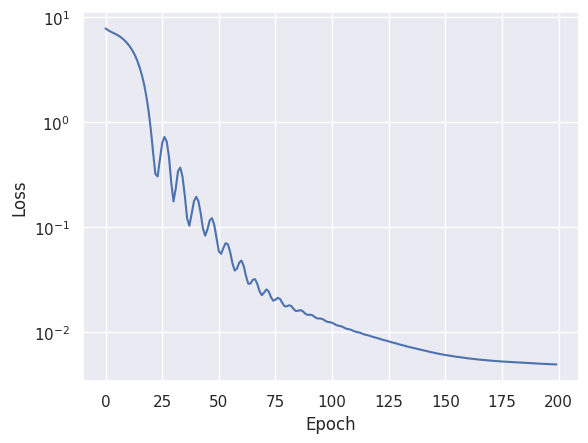

In [18]:
netdisc = NetDiscoveryWeighted(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss__weight, epochs=parameter_discovery_epochs, lr=1e-3).to(DEVICE)
print(f"data_loss_weight (loss1_weight): {netdisc.loss1_weight}, physics_loss_weight (loss2_weight): {netdisc.loss2_weight}")

losses = netdisc.fit(x_train_scaled, y_train_scaled)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Mean Squared Error: 2.8562
Discovered Cooling Rate (R): 0.004723
True Cooling Rate (R): 0.005


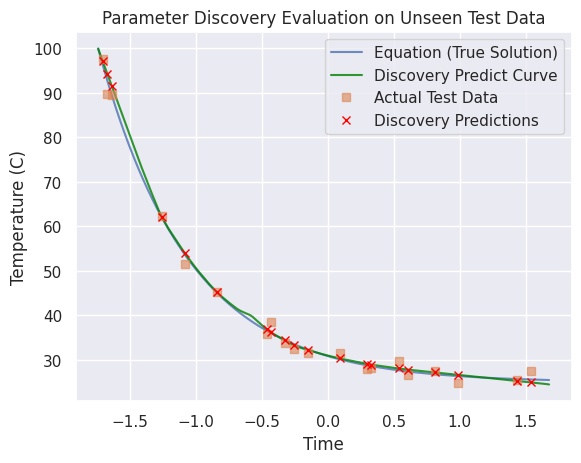

In [19]:
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32).to(DEVICE)
times_tensor = torch.tensor(times_scaled, dtype=torch.float32).to(DEVICE)

netdisc.eval()
with torch.no_grad():
    T_pred_scaled = netdisc(x_test_tensor).cpu().numpy()
    continuous_preds_scaled = netdisc(times_tensor).cpu().numpy()

T_pred_disc = y_scaler.inverse_transform(T_pred_scaled)
continuous_preds_disc = y_scaler.inverse_transform(continuous_preds_scaled)

test_mse_disc = np.mean((T_pred_disc.flatten() - y_test.flatten())**2)
discovered_r = netdisc.r.item()
true_r = 0.005

print(f"Mean Squared Error: {test_mse_disc:.4f}")
print(f"Discovered Cooling Rate (R): {discovered_r:.6f}")
print(f"True Cooling Rate (R): {true_r}")

plt.figure()

plt.plot(times_scaled, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times_scaled, continuous_preds_disc, label='Discovery Predict Curve', color='green', alpha=0.8)

plt.plot(x_test_scaled, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test_scaled, T_pred_disc, 'x', label='Discovery Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time')
plt.title('Parameter Discovery Evaluation on Unseen Test Data')
plt.show()